In [1]:
import pandas as pd
import plotly.express as px
df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [2]:
print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

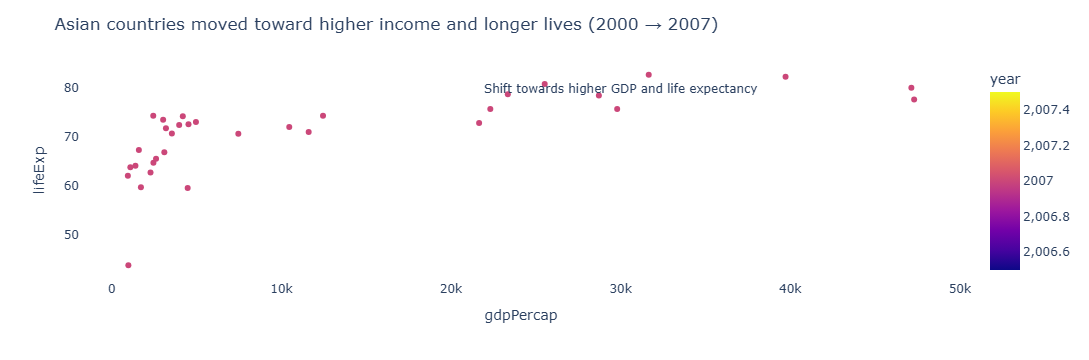

In [3]:
continent_choice = "Asia"

scatter_df = df[
    (df['continent'] == continent_choice) &
    (df['year'].isin([2000, 2007]))
]

fig = px.scatter(
    scatter_df,
    x="gdpPercap",
    y="lifeExp",
    color="year",
    hover_name="country",
    color_discrete_map={2000: "##D3D3D3", 2007: "#442220"}  # grey vs highlight
)

# Optional: add annotation showing general shift
fig.add_annotation(
    x=30000, y=80,
    text="Shift towards higher GDP and life expectancy",
    showarrow=False,
    font=dict(size=12)
)

fig.update_layout(
    title="Asian countries moved toward higher income and longer lives (2000 → 2007)",
    plot_bgcolor="white",
    paper_bgcolor="white"
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()

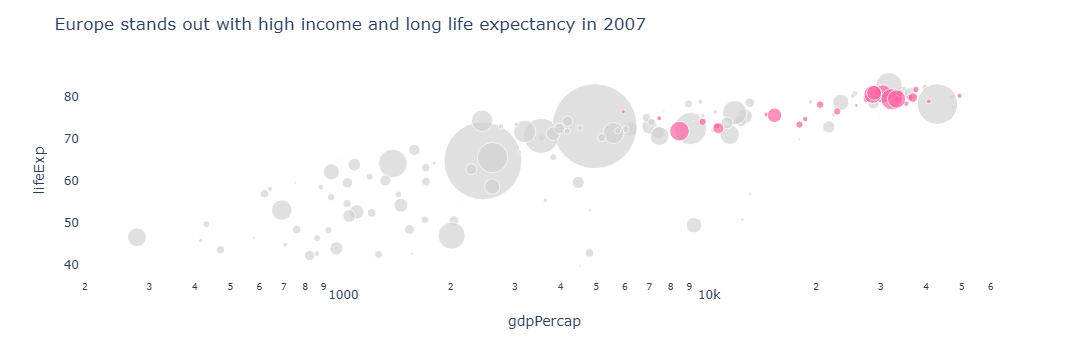

In [4]:
highlight_continent = "Europe"

bubble_df = df[df['year'] == 2007].copy()

# Create highlight vs rest
bubble_df['color_group'] = bubble_df['continent'].apply(
    lambda x: highlight_continent if x == highlight_continent else "Other"
)

fig = px.scatter(
    bubble_df,
    x="gdpPercap",
    y="lifeExp",
    size="pop",
    color="color_group",
    hover_name="country",
    log_x=True,
    size_max=60,
    color_discrete_map={
        highlight_continent: "#fe64a3",
        "Other": "#D3D3D3"
    }
)

# Add annotation for story
fig.add_annotation(
    x=40000,
    y=80,
    text="European countries cluster at high income & high life expectancy",
    showarrow=False,
    font=dict(size=12)
)

fig.update_layout(
    title="Europe stands out with high income and long life expectancy in 2007",
    plot_bgcolor="white",
    paper_bgcolor="white",
    showlegend=False
)

fig.update_xaxes(showgrid=False)
fig.update_yaxes(showgrid=False)

fig.show()